In [1]:
import sys
from pathlib import Path
from dataset import *
from pino_utils import VTCMHDF5MapStyleDataset, create_vtcm_hdf5_dataloader

train_h5 = "/workspace/VTCM_PYTHON/datasets/VTCM_vertical/train.hdf5"
ds = VTCMHDF5MapStyleDataset(train_h5, device="cpu", preload_to_memory=False)
print(f"Dataset size: {len(ds)}")
sample = ds[0]
print(f"keys: {list(sample.keys())}")
print(f"input: {sample['input'].shape}")
print(f"output: {sample['output'].shape}")


Dataset size: 62240
keys: ['input', 'output', 'init_state', 'dt', 'window_start', 'window_end', 'source_file', 'vehicle_params', 'rail_params', 'fastener_params', 'subrail_params', 'line_params', 'vx_mps']
input: torch.Size([2, 256])
output: torch.Size([21, 256])


In [2]:
print(sample.keys())

dict_keys(['input', 'output', 'init_state', 'dt', 'window_start', 'window_end', 'source_file', 'vehicle_params', 'rail_params', 'fastener_params', 'subrail_params', 'line_params', 'vx_mps'])


input shape: (2, 256)
output shape: (21, 256)


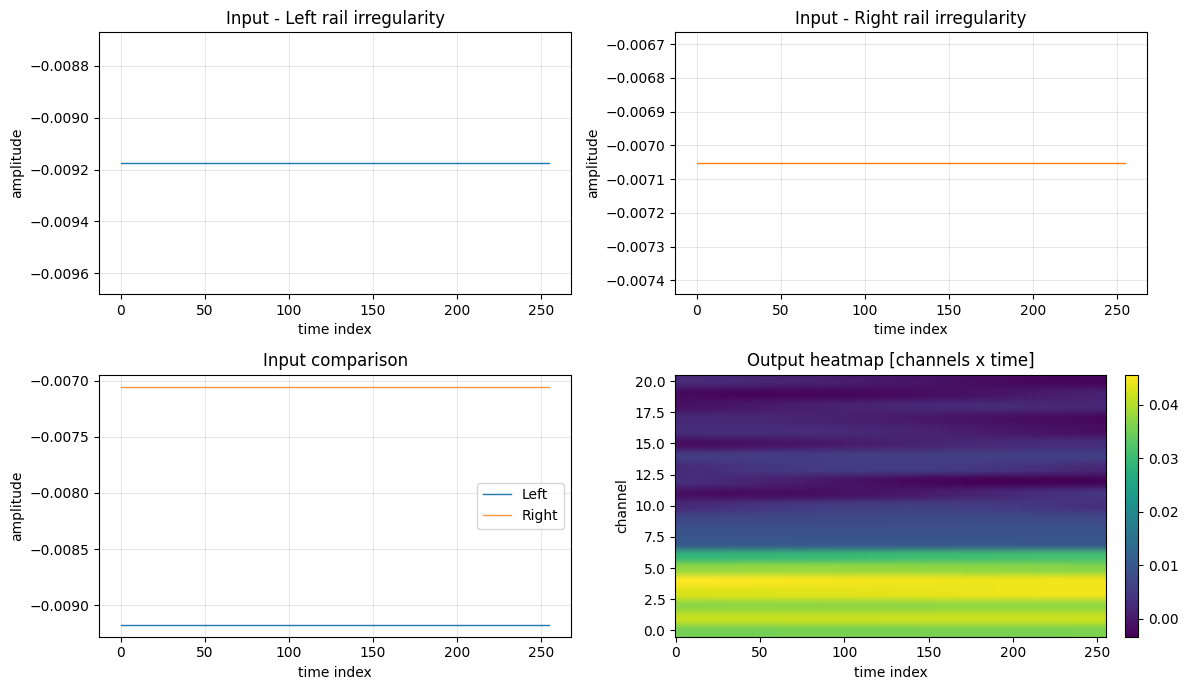

In [3]:
import matplotlib.pyplot as plt
import numpy as np

u = sample["input"].detach().cpu().numpy()    # [2, T]
y = sample["output"].detach().cpu().numpy()   # [C, T]

print("input shape:", u.shape)
print("output shape:", y.shape)

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# 左轨激励
axes[0, 0].plot(u[0], lw=1.0, color="tab:blue")
axes[0, 0].set_title("Input - Left rail irregularity")
axes[0, 0].set_xlabel("time index")
axes[0, 0].set_ylabel("amplitude")
axes[0, 0].grid(True, alpha=0.3)

# 右轨激励
axes[0, 1].plot(u[1], lw=1.0, color="tab:orange")
axes[0, 1].set_title("Input - Right rail irregularity")
axes[0, 1].set_xlabel("time index")
axes[0, 1].set_ylabel("amplitude")
axes[0, 1].grid(True, alpha=0.3)

# 左右轨对比
axes[1, 0].plot(u[0], lw=1.0, label="Left")
axes[1, 0].plot(u[1], lw=1.0, label="Right", alpha=0.8)
axes[1, 0].set_title("Input comparison")
axes[1, 0].set_xlabel("time index")
axes[1, 0].set_ylabel("amplitude")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 输出热力图 [C, T]
im = axes[1, 1].imshow(y, aspect="auto", cmap="viridis", origin="lower")
axes[1, 1].set_title("Output heatmap [channels x time]")
axes[1, 1].set_xlabel("time index")
axes[1, 1].set_ylabel("channel")
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

=== 归一化统计信息 ===
input mean: [[8.2462257e-06 6.3726793e-06]]
input std: [[0.00089867 0.00090357]]
output mean shape: (1, 21)
output std shape: (1, 21)

=== 归一化后的数据 ===
input (normalized) shape: (2, 256), min: -0.009176, max: -0.007053
output (normalized) shape: (21, 256), min: -0.003367, max: 0.045572

=== 反归一化后的数据 ===
input (denormalized) shape: (2, 256), min: 0.000000, max: 0.000000
output (denormalized) shape: (21, 256), min: -0.009711, max: 0.009521


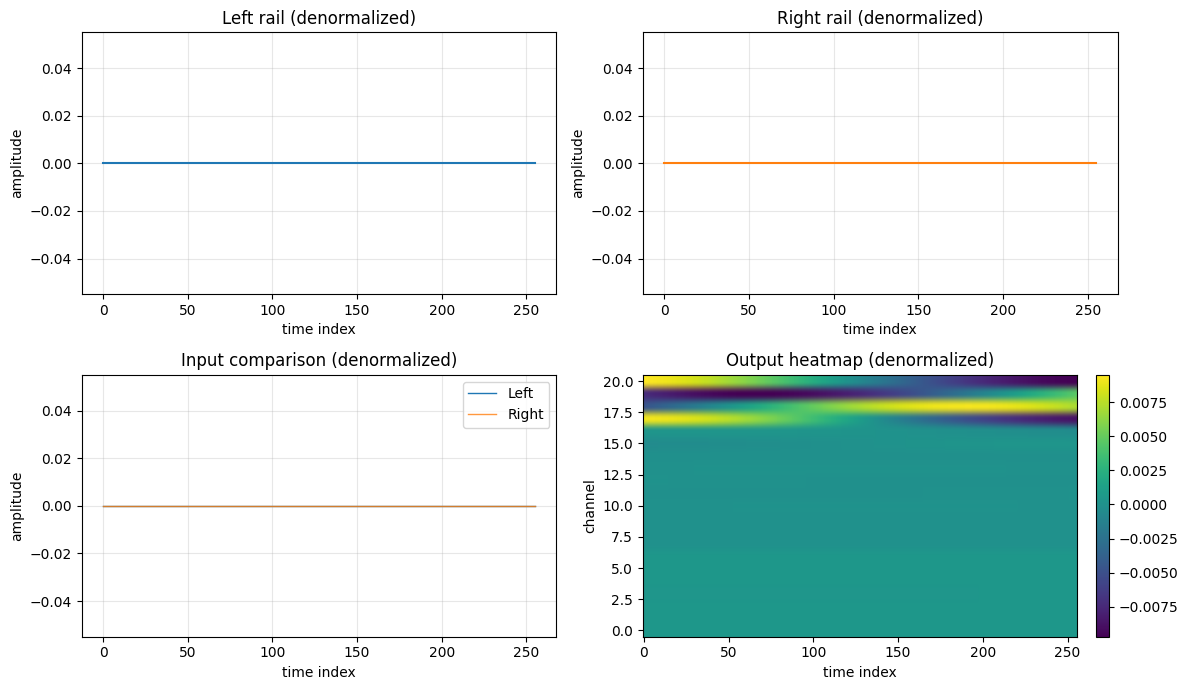


✓ 反归一化测试完成


In [4]:
# 测试反归一化
import numpy as np

# 加载归一化统计信息
norm_stats_path = "/workspace/VTCM_PYTHON/datasets/VTCM_vertical/norm_stats.npz"
norm_stats = np.load(norm_stats_path)

u_mean = norm_stats['u_mean']   # shape: (1, 2)
u_std = norm_stats['u_std']     # shape: (1, 2)
X_mean = norm_stats['X_mean']   # shape: (1, 21)
X_std = norm_stats['X_std']     # shape: (1, 21)

print("=== 归一化统计信息 ===")
print(f"input mean: {u_mean}")
print(f"input std: {u_std}")
print(f"output mean shape: {X_mean.shape}")
print(f"output std shape: {X_std.shape}")

# 获取原始数据（已归一化）
u_normalized = sample['input'].detach().cpu().numpy()  # [2, 256]
y_normalized = sample['output'].detach().cpu().numpy()  # [21, 256]

print(f"\n=== 归一化后的数据 ===")
print(f"input (normalized) shape: {u_normalized.shape}, min: {u_normalized.min():.6f}, max: {u_normalized.max():.6f}")
print(f"output (normalized) shape: {y_normalized.shape}, min: {y_normalized.min():.6f}, max: {y_normalized.max():.6f}")

# 反归一化
u_denorm = u_normalized * u_std.T + u_mean.T  # [2, 256] * [2, 1] + [2, 1]
y_denorm = y_normalized * X_std.T + X_mean.T  # [21, 256] * [21, 1] + [21, 1]

print(f"\n=== 反归一化后的数据 ===")
print(f"input (denormalized) shape: {u_denorm.shape}, min: {u_denorm.min():.6f}, max: {u_denorm.max():.6f}")
print(f"output (denormalized) shape: {y_denorm.shape}, min: {y_denorm.min():.6f}, max: {y_denorm.max():.6f}")

# 可视化反归一化结果
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# 反归一化 - 左轨
axes[0, 0].plot(u_denorm[0], lw=1.5, color="tab:blue")
axes[0, 0].set_title("Left rail (denormalized)")
axes[0, 0].set_xlabel("time index")
axes[0, 0].set_ylabel("amplitude")
axes[0, 0].grid(True, alpha=0.3)

# 反归一化 - 右轨
axes[0, 1].plot(u_denorm[1], lw=1.5, color="tab:orange")
axes[0, 1].set_title("Right rail (denormalized)")
axes[0, 1].set_xlabel("time index")
axes[0, 1].set_ylabel("amplitude")
axes[0, 1].grid(True, alpha=0.3)

# 反归一化 - 左右轨对比
axes[1, 0].plot(u_denorm[0], lw=1.0, label="Left")
axes[1, 0].plot(u_denorm[1], lw=1.0, label="Right", alpha=0.8)
axes[1, 0].set_title("Input comparison (denormalized)")
axes[1, 0].set_xlabel("time index")
axes[1, 0].set_ylabel("amplitude")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 输出反归一化热力图
im = axes[1, 1].imshow(y_denorm, aspect="auto", cmap="viridis", origin="lower")
axes[1, 1].set_title("Output heatmap (denormalized)")
axes[1, 1].set_xlabel("time index")
axes[1, 1].set_ylabel("channel")
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\n✓ 反归一化测试完成")

=== 重构完整片段演示 ===

第一个样本的窗口信息:
  window_start: 20896
  window_end: 21152
  source_file: b'/workspace/VTCM_PYTHON/results/pino_train_dataset/\xe9\xab\x98\xe9\x80\x9f\xe5\xae\xa2\xe8\xbd\xa6-\xe9\x9a\x8f\xe6\x9c\xba\xe4\xb8\x8d\xe5\xb9\xb3\xe9\xa1\xba-vehicle-standard-20260325_002913/files/simulation_result.npz'

搜索文件 b'/workspace/VTCM_PYTHON/results/pino_train_dataset/\xe9\xab\x98\xe9\x80\x9f\xe5\xae\xa2\xe8\xbd\xa6-\xe9\x9a\x8f\xe6\x9c\xba\xe4\xb8\x8d\xe5\xb9\xb3\xe9\xa1\xba-vehicle-standard-20260325_002913/files/simulation_result.npz' 的所有样本...
找到 2 个样本来自同一文件

窗口信息:
  idx=    0, start=20896, end=21152
  idx=   68, start=47648, end=47904

重构完整序列...
完整序列长度: 47904 个时间步
✓ 重构完成
  input shape: (2, 47904)
  output shape: (21, 47904)

绘制完整片段...


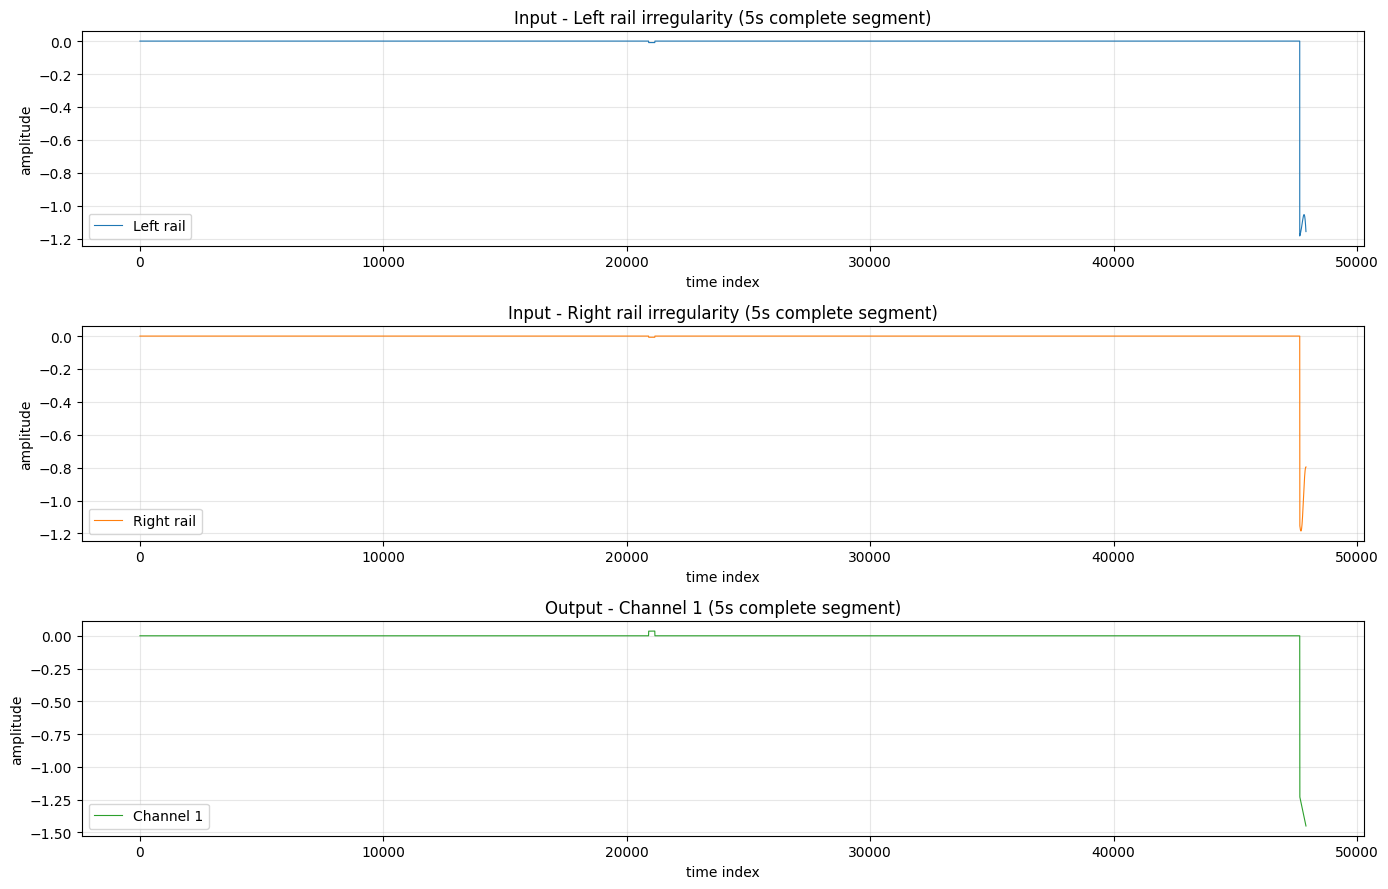


✓ 完整片段绘制完成


In [5]:
# 重构完整的5秒片段
print("=== 重构完整片段演示 ===\n")

# 1. 查看数据窗口信息
print("第一个样本的窗口信息:")
print(f"  window_start: {sample['window_start']}")
print(f"  window_end: {sample['window_end']}")
print(f"  source_file: {sample['source_file']}")

# 查找同一个文件的所有样本
source_file = sample['source_file']
print(f"\n搜索文件 {source_file} 的所有样本...")

matching_indices = []
for idx in range(min(100, len(ds))):  # 检查前100个样本
    s = ds[idx]
    if s['source_file'] == source_file:
        matching_indices.append(idx)

print(f"找到 {len(matching_indices)} 个样本来自同一文件")

if len(matching_indices) > 1:
    # 按window_start排序
    segments = []
    for idx in matching_indices:
        s = ds[idx]
        segments.append({
            'idx': idx,
            'window_start': s['window_start'],
            'window_end': s['window_end'],
            'input': s['input'].detach().cpu().numpy(),
            'output': s['output'].detach().cpu().numpy(),
        })
    
    segments = sorted(segments, key=lambda x: x['window_start'])
    
    print("\n窗口信息:")
    for seg in segments[:5]:  # 显示前5个窗口
        print(f"  idx={seg['idx']:5d}, start={seg['window_start']:5d}, end={seg['window_end']:5d}")
    
    # 2. 重构完整序列（使用平均来处理重叠部分）
    print("\n重构完整序列...")
    
    seq_length = 256
    stride = 128
    
    # 计算完整序列的长度
    full_length = segments[-1]['window_end']
    print(f"完整序列长度: {full_length} 个时间步")
    
    # 创建输出缓冲区（使用加权平均）
    u_reconstructed = np.zeros((2, full_length))
    y_reconstructed = np.zeros((21, full_length))
    weights = np.zeros(full_length)
    
    for seg in segments:
        start = seg['window_start']
        end = seg['window_end']
        u_reconstructed[:, start:end] += seg['input']
        y_reconstructed[:, start:end] += seg['output']
        weights[start:end] += 1
    
    # 加权平均处理重叠区域
    for t in range(full_length):
        if weights[t] > 0:
            u_reconstructed[:, t] /= weights[t]
            y_reconstructed[:, t] /= weights[t]
    
    print(f"✓ 重构完成")
    print(f"  input shape: {u_reconstructed.shape}")
    print(f"  output shape: {y_reconstructed.shape}")
    
    # 3. 绘制完整5秒的输入和输出第一通道
    print("\n绘制完整片段...")
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 9))
    
    # 左轨输入
    axes[0].plot(u_reconstructed[0], lw=0.8, color="tab:blue", label="Left rail")
    axes[0].set_title("Input - Left rail irregularity (5s complete segment)")
    axes[0].set_xlabel("time index")
    axes[0].set_ylabel("amplitude")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # 右轨输入
    axes[1].plot(u_reconstructed[1], lw=0.8, color="tab:orange", label="Right rail")
    axes[1].set_title("Input - Right rail irregularity (5s complete segment)")
    axes[1].set_xlabel("time index")
    axes[1].set_ylabel("amplitude")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # 输出第一通道
    axes[2].plot(y_reconstructed[0], lw=0.8, color="tab:green", label="Channel 1")
    axes[2].set_title("Output - Channel 1 (5s complete segment)")
    axes[2].set_xlabel("time index")
    axes[2].set_ylabel("amplitude")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ 完整片段绘制完成")
else:
    print(f"同一文件的样本数不足，跳过重构演示")

=== train_full_seq.hdf5 内容 ===
  dt: shape=(160,), dtype=float32
  fastener_params: shape=(160, 5), dtype=float32
  input: shape=(160, 2, 50000), dtype=float32
  line_params: shape=(160, 15), dtype=float32
  output: shape=(160, 21, 50000), dtype=float32
  rail_params: shape=(160, 16), dtype=float32
  seq_lengths: shape=(160,), dtype=int32
  source_file: shape=(160,), dtype=object
  subrail_params: shape=(160, 13), dtype=float32
  vehicle_params: shape=(160, 40), dtype=float32
  vx_mps: shape=(160,), dtype=float32

文件属性: {'T_max': 50000, 'components': 'disp,vel,acc', 'format': 'VTCM_vertical_full_seq_v1', 'skip_initial_seconds': 2.0, 'z_dof_indices': '1,6,11,16,21,26,31'}

[167.9 ms] 读取完成
  source_file : /workspace/VTCM_PYTHON/results/pino_train_dataset/高速客车-随机不平顺-vehicle-standard-20260326_043701/files/simulation_result.npz
  T_max (padded) = 50000，T_real (有效) = 50000
  dt = 1.0e-04 s  →  有效时长 = 5.00 s
  input  shape: (2, 50000)
  output shape: (21, 50000)


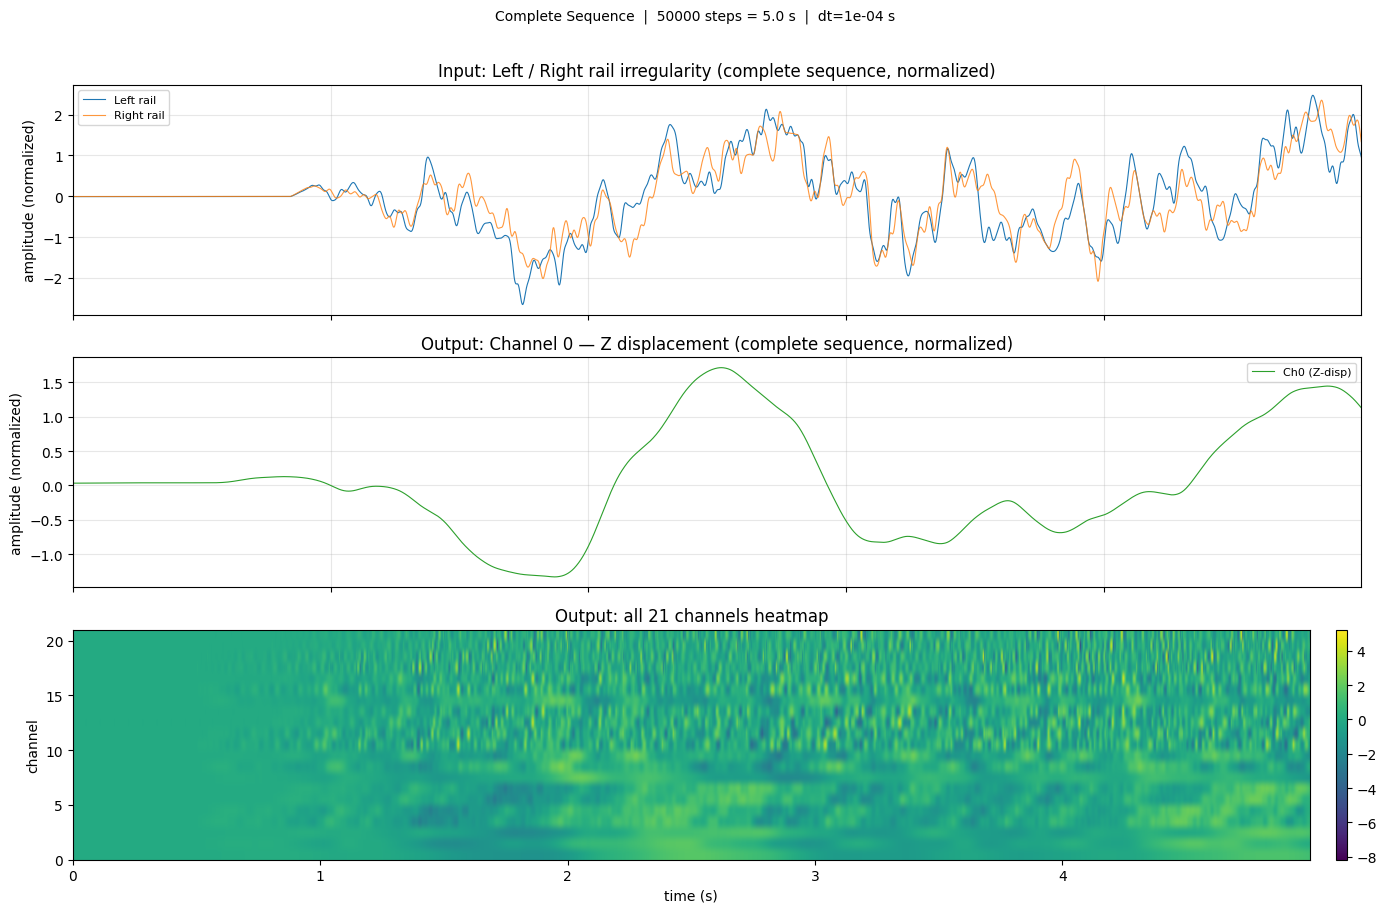

In [6]:
import h5py
import time

# ── 直接从完整序列 HDF5 读取，无需重构 ──
full_seq_h5 = "/workspace/VTCM_PYTHON/datasets/VTCM_vertical/train_full_seq.hdf5"

t0 = time.perf_counter()

with h5py.File(full_seq_h5, "r") as f:
    # 查看文件结构
    print("=== train_full_seq.hdf5 内容 ===")
    for k in f.keys():
        ds = f[k]
        print(f"  {k}: shape={ds.shape}, dtype={ds.dtype}")
    print(f"\n文件属性: { {k: v for k, v in f.attrs.items()} }")

    # 读取第 0 个仿真文件的完整序列
    idx = 0
    u_full = f["input"][idx]           # (2, T_max)
    y_full = f["output"][idx]          # (21, T_max)
    T_real = int(f["seq_lengths"][idx])  # 实际有效步数（去除 zero-padding）
    dt_val = float(f["dt"][idx])
    src    = f["source_file"][idx]
    if isinstance(src, bytes):
        src = src.decode("utf-8")

t1 = time.perf_counter()
print(f"\n[{(t1-t0)*1000:.1f} ms] 读取完成")
print(f"  source_file : {src}")
print(f"  T_max (padded) = {u_full.shape[1]}，T_real (有效) = {T_real}")
print(f"  dt = {dt_val:.1e} s  →  有效时长 = {T_real * dt_val:.2f} s")
print(f"  input  shape: {u_full.shape}")
print(f"  output shape: {y_full.shape}")

# 截取有效部分（去除 zero-padding）
u_full = u_full[:, :T_real]   # (2,  T_real)
y_full = y_full[:, :T_real]   # (21, T_real)

time_axis = np.arange(T_real) * dt_val  # 以秒为单位

# ── 可视化 ──
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(time_axis, u_full[0], lw=0.8, color="tab:blue",   label="Left rail")
axes[0].plot(time_axis, u_full[1], lw=0.8, color="tab:orange", label="Right rail", alpha=0.8)
axes[0].set_title("Input: Left / Right rail irregularity (complete sequence, normalized)")
axes[0].set_ylabel("amplitude (normalized)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_axis, y_full[0], lw=0.8, color="tab:green", label="Ch0 (Z-disp)")
axes[1].set_title("Output: Channel 0 — Z displacement (complete sequence, normalized)")
axes[1].set_ylabel("amplitude (normalized)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

im = axes[2].imshow(y_full, aspect="auto", cmap="viridis", origin="lower",
                    extent=[0, T_real * dt_val, 0, y_full.shape[0]])
axes[2].set_title("Output: all 21 channels heatmap")
axes[2].set_xlabel("time (s)")
axes[2].set_ylabel("channel")
fig.colorbar(im, ax=axes[2], fraction=0.02, pad=0.02)

plt.suptitle(f"Complete Sequence  |  {T_real} steps = {T_real * dt_val:.1f} s  |  dt={dt_val:.0e} s",
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

In [9]:
import matplotlib.pyplot as plt

def dataset_gen():
    """读取某个hdf5数据集，打印其keys和shape"""
    h5_path = "/workspace/VTCM_PYTHON/datasets/VTCM_vertical/train.hdf5"
    with h5py.File(h5_path, "r") as f:
        print(f"=== 数据集 {h5_path} 内容 ===")
        for k in f.keys():
            ds = f[k]
            print(f"  {k}: shape={ds.shape}, dtype={ds.dtype}")
        print(f"\n文件属性: { {k: v for k, v in f.attrs.items()} }")
dataset_gen()

=== 数据集 /workspace/VTCM_PYTHON/datasets/VTCM_vertical/train.hdf5 内容 ===
  dt: shape=(62240,), dtype=float32
  fastener_params: shape=(62240, 5), dtype=float32
  init_state: shape=(62240, 21), dtype=float32
  input: shape=(62240, 2, 256), dtype=float32
  line_params: shape=(62240, 15), dtype=float32
  output: shape=(62240, 21, 256), dtype=float32
  rail_params: shape=(62240, 16), dtype=float32
  source_file: shape=(62240,), dtype=object
  subrail_params: shape=(62240, 13), dtype=float32
  vehicle_params: shape=(62240, 40), dtype=float32
  vx_mps: shape=(62240,), dtype=float32
  window_end: shape=(62240,), dtype=int32
  window_start: shape=(62240,), dtype=int32

文件属性: {'components': 'disp,vel,acc', 'format': 'VTCM_vertical_time_series_v1', 'seq_length': 256, 'stride': 128, 'z_dof_indices': '1,6,11,16,21,26,31'}


In [ ]:
import Pa
from ..LNN.VTCM_solver import *

ImportError: attempted relative import with no known parent package